# H3 — LDI Post > Mid > Pre

Simple paired t-tests (one-sided):
- Post > Mid
- Mid > Pre
- Post > Pre

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel

sns.set(style='whitegrid', context='talk')

df = pd.read_csv(r'C:\Users\Satyajit\Desktop\BRSM EXP\DATA\compiled_preprocessed.csv')
df['boundary_position'] = pd.Categorical(df['boundary_position'], categories=['Pre', 'Mid', 'Post'], ordered=True)

In [2]:
def p_resp(data, trial_type, response, boundary=None):
    x = data[data['trial_type'] == trial_type]
    if boundary is not None:
        x = x[x['boundary_position'] == boundary]
    if x.empty:
        return np.nan
    return (x['user_response'] == response).mean()

rows = []
for (pid, cond), sub in df.groupby(['participant_id', 'condition']):
    foil_sim = p_resp(sub, 'Foil', 'Lure')
    rows.append({
        'id': f'{cond}_{int(pid)}',
        'LDI_pre': p_resp(sub, 'Lure', 'Lure', 'Pre') - foil_sim,
        'LDI_mid': p_resp(sub, 'Lure', 'Lure', 'Mid') - foil_sim,
        'LDI_post': p_resp(sub, 'Lure', 'Lure', 'Post') - foil_sim
    })

wide = pd.DataFrame(rows).dropna()
print('Complete participants:', len(wide))
display(wide[['LDI_pre', 'LDI_mid', 'LDI_post']].mean().to_frame('mean').T)

Complete participants: 158


,LDI_pre,LDI_mid,LDI_post
mean,0.322152,0.331013,0.32057


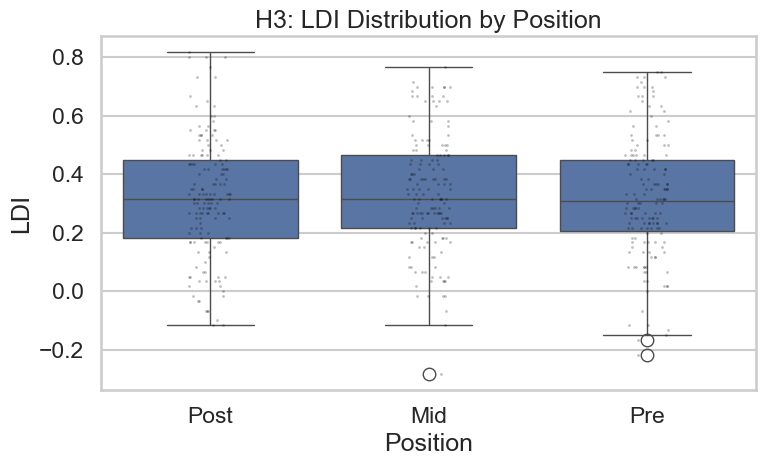

In [3]:
# Visualization: participant-level LDI distributions by position
long = wide.melt(value_vars=['LDI_pre', 'LDI_mid', 'LDI_post'], var_name='position', value_name='LDI')
long['position'] = long['position'].str.replace('LDI_', '').str.capitalize()

plt.figure(figsize=(8, 5))
sns.boxplot(data=long, x='position', y='LDI', order=['Post', 'Mid', 'Pre'])
sns.stripplot(data=long, x='position', y='LDI', order=['Post', 'Mid', 'Pre'], color='black', alpha=0.25, size=2)
plt.title('H3: LDI Distribution by Position')
plt.xlabel('Position')
plt.ylabel('LDI')
plt.tight_layout()
plt.show()

In [4]:
tests = []
for a, b in [('LDI_post', 'LDI_mid'), ('LDI_mid', 'LDI_pre'), ('LDI_post', 'LDI_pre')]:
    test = ttest_rel(wide[a], wide[b], alternative='greater')
    tests.append({
        'comparison': f'{a} > {b}',
        'mean_diff': (wide[a] - wide[b]).mean(),
        't_stat': test.statistic,
        'p_value': test.pvalue,
        'supported (p<.05)': test.pvalue < 0.05
    })

result_df = pd.DataFrame(tests)
display(result_df)

,comparison,mean_diff,t_stat,p_value,supported (p<.05)
0,LDI_post > LDI_mid,-0.010443,-0.827546,0.795408,False
1,LDI_mid > LDI_pre,0.008861,0.770853,0.220976,False
2,LDI_post > LDI_pre,-0.001582,-0.130225,0.551723,False


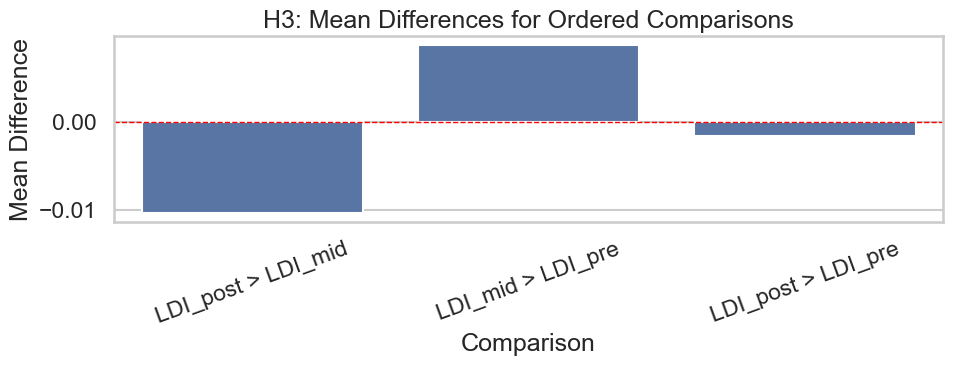

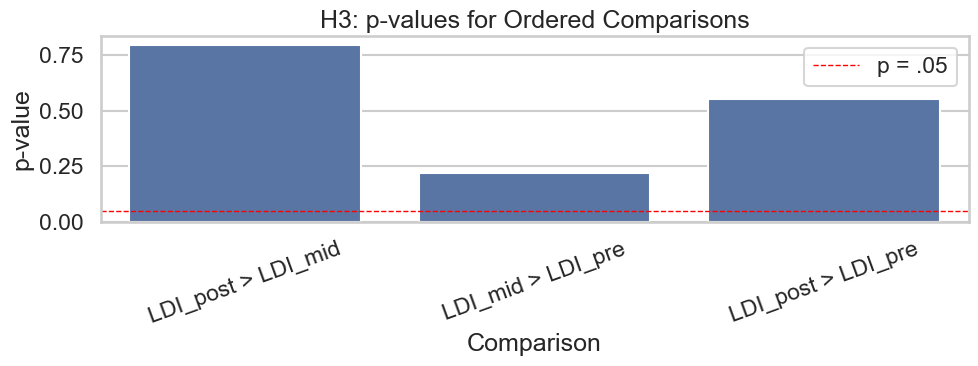

In [5]:
# Visualization: mean differences and p-values from paired tests
plot_df = result_df.copy()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x='comparison', y='mean_diff')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('H3: Mean Differences for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('Mean Difference')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df, x='comparison', y='p_value')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='p = .05')
plt.title('H3: p-values for Ordered Comparisons')
plt.xlabel('Comparison')
plt.ylabel('p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()